In [2]:
import cv2
import torch
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
import albumentations as A

# HARDWARE CHECK
if torch.cuda.is_available():
    device = 0
    gpu_name = torch.cuda.get_device_name(0)
    print(f"SUCCESS: High-Performance GPU Detected: {gpu_name}")
    print("Training will be fast.")
else:
    device = 'cpu'
    print("WARNING: No GPU detected. We are using the CPU.")
    print("Training will be extremely slow (hours or days).")

SUCCESS: High-Performance GPU Detected: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Training will be fast.


In [2]:
dataset_root = "/home/akash/Project Exhibition/Final_Implementation/Aircraft Defect Detection.v3-no-nulls.yolov8"

yaml_content = f"""
path: {dataset_root}
train: train/images
val: valid/images
test: test/images

nc: 3
names: ['Dent', 'Fastener Damage', 'Rupture']
"""

with open("aircraft_defects.yaml", "w") as f:
    f.write(yaml_content)

print("YAML created: aircraft_defects.yaml")
print(f"Pointing to dataset at: {dataset_root}")

YAML created: aircraft_defects.yaml
Pointing to dataset at: /home/akash/Project Exhibition/Final_Implementation/Aircraft Defect Detection.v3-no-nulls.yolov8


In [3]:
transform_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

print("Augmentation Pipeline Built.")
print("Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).")
print("This matches the methodology to increase dataset diversity.")


Augmentation Pipeline Built.
Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).
This matches the methodology to increase dataset diversity.


In [4]:
model = YOLO('yolov8s.pt')  

print("Model loaded: YOLOv8s (Small).")
print("Status: Ready for Fine-Tuning.")

Model loaded: YOLOv8s (Small).
Status: Ready for Fine-Tuning.


In [ ]:
results = model.train(
    data="aircraft_defects.yaml",   # your generated YAML
    epochs=150,                    # long training (good for accuracy)
    imgsz=640,                     # safe default
    batch=8,                       # SAFE for 6GB (reduce if crash)
    workers=2,                     # avoid RAM overload
    device=0,                      # GPU
    patience=50,                   # prevents early stopping too soon
    cache=False,                   # IMPORTANT: avoids RAM overflow
    amp=True,                      # mixed precision → saves VRAM
    lr0=0.01,                      # stable learning rate
    optimizer="SGD",               # more stable than Adam sometimes
    project="runs/detect",
    name="yolov8_aircraft_safe",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=aircraft_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n


0: 1280x1280 1 Dent, 1 Fastener Damage, 37.9ms
1: 1280x1280 2 Ruptures, 37.9ms
2: 1280x1280 1 Fastener Damage, 1 Rupture, 37.9ms
Speed: 7.9ms preprocess, 37.9ms inference, 1.5ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /home/akash/Project Exhibition/Final_Implementation/runs/detect/predict2


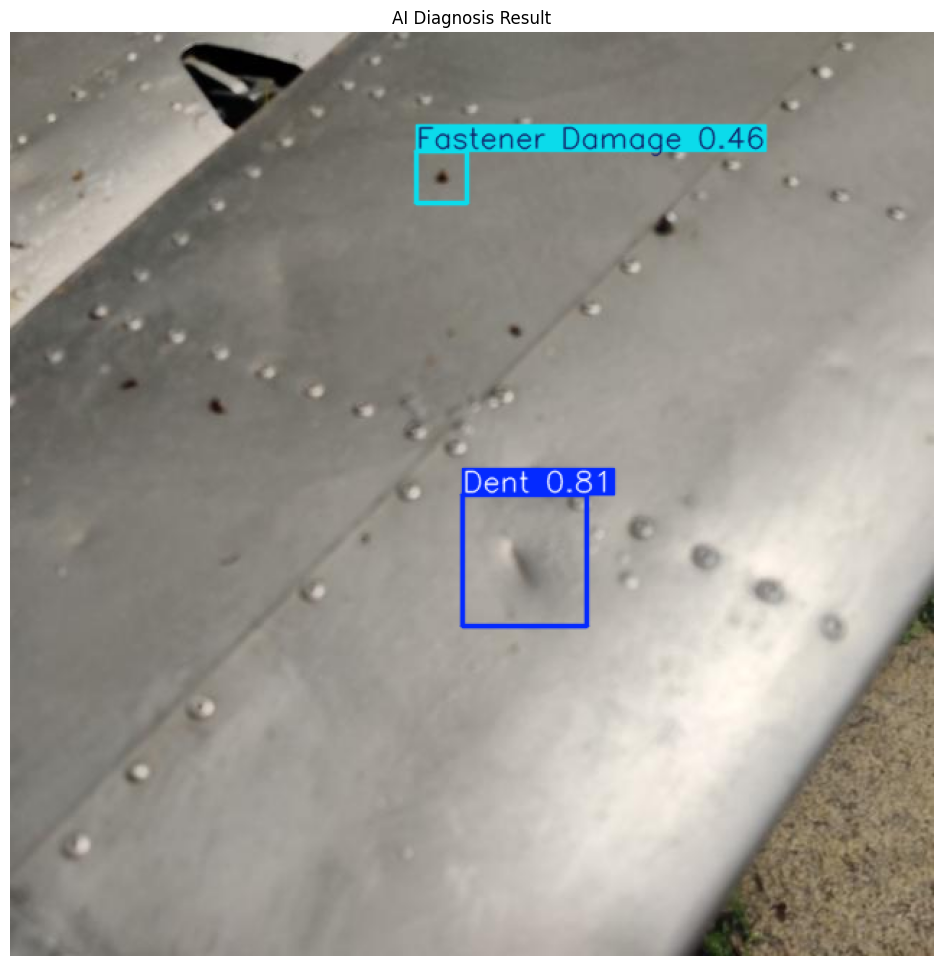

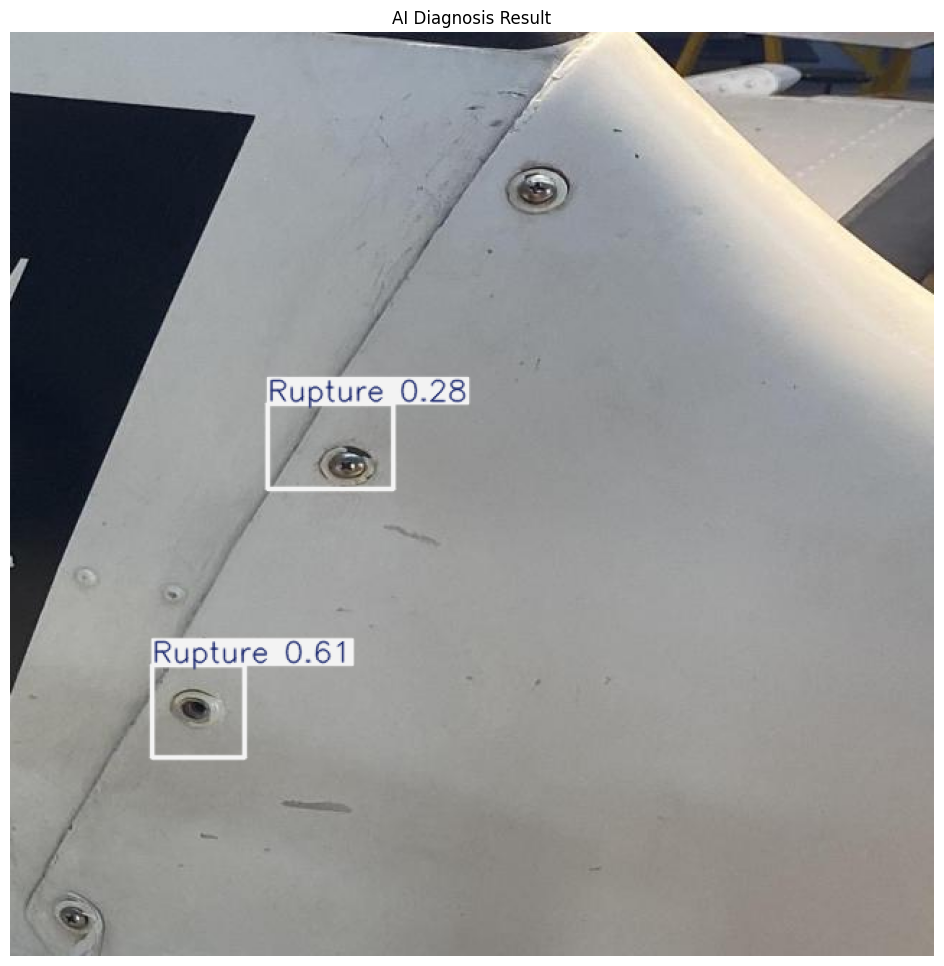

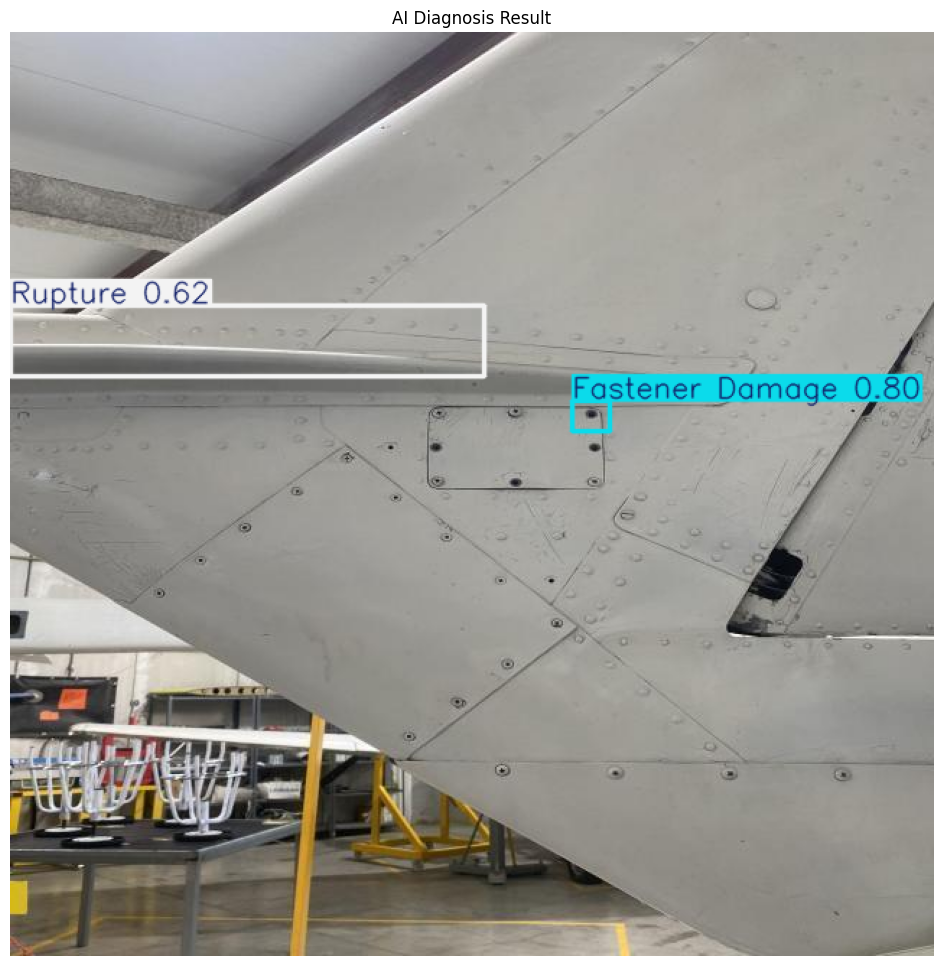

In [4]:
best_model_path = 'runs/detect/runs/detect/yolov8_aircraft_safe/weights/best.pt'
model = YOLO(best_model_path)

import glob
test_images = glob.glob("/home/akash/Project Exhibition/Final_Implementation/Aircraft Defect Detection.v3-no-nulls.yolov8/test/images/*.jpg") 

# 3. Pick 3 random images to show
if len(test_images) > 0:
    selected_images = random.sample(test_images, min(3, len(test_images)))
    
    results = model.predict(selected_images, conf=0.25, imgsz=1280, save=True)
    
    for result in results:
        im_array = result.plot()
        
        plt.figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("AI Diagnosis Result")
        plt.show()
else:
    print("No images found in test/images. Check the folder path.")